In [2]:
#1. basic information
def display_basic_info(df):
    print(f"Number of rows and columns:{df.shape}")
    print(f"Columns:{df.columns}")
    print(f"Datatype of the columns:\n{df.dtypes}")
    print(df.info())
                                    

In [3]:
#step2: data quality checks
def data_quality_checks(df):
    print(f"Percentage of missing values:\n{((df.isnull().sum()/len(df))*100).round(2).sort_values(ascending=False)}\n\n")
    print(f"Percentage of duplicates:{((df.duplicated().sum()/len(df))*100).round(2)}")
    
    print("Object columns that may be numeric:\n")
    for col in df.select_dtypes(include="object").columns:
    # Try converting to numeric
        converted = pd.to_numeric(df[col], errors="coerce")
    # If every non-null value could be converted, it's probably numeric
        if converted.notna().sum() == df[col].notna().sum():
            print(f"{col} may be stored as object but contains numeric values.")

In [4]:
def get_target_column(df):
    print("\nAvailable Columns:")
    print("-" * 40)
    for i, col in enumerate(df.columns, start=1):
        print(f"{i}. {col}")
    while True:
        try:
            choice = int(input("\nEnter the number corresponding to the target column: "))

            if 1 <= choice <= len(df.columns):
                target = df.columns[choice - 1]
                print(f"\nSelected Target: {target}")
                return target
            else:
                print("Invalid choice. Please enter a valid column number.")
        except ValueError:
            print("Please enter a numeric value.")

In [5]:
import pandas as pd

def detect_problem_type(df, target):
    y = df[target]
    if pd.api.types.is_numeric_dtype(y):
        unique = y.nunique()
        total = len(y)
        if unique <= max(10, int(0.05 * total)):
            detected = "Classification"
        else:
            detected = "Regression"

    else:
        # Object, category, bool
        detected = "Classification"

    print(f"\nDetected Problem Type : {detected}")
    while True:
        choice = input(
            "Press Enter to accept or type "
            "'R' for Regression or 'C' for Classification: "
        ).strip().upper()

        if choice == "":
            return detected

        elif choice == "R":
            return "Regression"

        elif choice == "C":
            return "Classification"

        else:
            print("Invalid input. Please press Enter, R, or C.")

In [6]:
def classify_features(df):
    #identifying numeric,categorical features
    numeric_cols=df.select_dtypes(include='number').columns.tolist()
    categorical_cols=df.select_dtypes(include=['object','bool','category']).columns.tolist()           #extract col names and append to a list
    
    for col in numeric_cols.copy():
        if df[col].nunique() <= 10:
            print(col)
            numeric_cols.remove(col)
            categorical_cols.append(col)
    
    for col in categorical_cols.copy():
        if df[col].nunique() >= 10:
            categorical_cols.remove(col)

    return numeric_cols,categorical_cols
    

In [13]:
#Univariate analysis 
def univariate_analysis(df,numeric_cols,categorical_cols):
    #Visualisation:Categorical features:
    for col in categorical_cols:
        df_category=df[col].value_counts()
        plt.bar(df_category.index,df_category.values)
        plt.xlabel(df_category.index)
        plt.ylabel(df_category.values)
        plt.title(f"Univariate analysis of {col}")
        plt.show()
        print(df_category)
    n=len(numeric_cols)
    figure, axes = plt.subplots(
        n, 3,
        figsize=(15, 5*n),
        squeeze=False
    )
    #Visualisation:numeric features
    for i, col in enumerate(numeric_cols):
    
        # Histogram
        axes[i,0].hist(df[col].dropna(), bins="auto")
        axes[i,0].set_title(f"Histogram - {col}")
        axes[i,0].set_xlabel(col)
        axes[i,0].set_ylabel("Frequency")
    
        # Boxplot
        axes[i,1].boxplot(df[col].dropna(), vert=False)
        axes[i,1].set_title(f"Boxplot - {col}")
    
        # KDE
        sns.kdeplot(df[col].dropna(), ax=axes[i,2])
        axes[i,2].set_title(f"KDE - {col}")
    
    plt.tight_layout()
    plt.show()
    

In [15]:
def display_descriptive_statistics(df,numeric_cols):
    for col in numeric_cols:
        print(f"\n\nFeature: {col}")
        # Descriptive statistics
        print("\nDescriptive Statistics:")
        print(df[col].describe())
    
        skew = df[col].skew()
        print(f"\nSkewness: {skew:.2f}")
    
        if -0.5 <= skew <= 0.5:
            print("Approximately symmetric (normal).")
    
        elif -1 <= skew < -0.5:
            print("Moderately left-skewed.")
    
        elif skew < -1:
            print("Highly left-skewed.")
    
        elif 0.5 < skew <= 1:
            print("Moderately right-skewed.")
    
        else:  # skew > 1
            print("Highly right-skewed.")

In [8]:
#outlier analysis
def outlier_detection(df,numeric_cols):
    for col in numeric_cols:
        q1=df[col].quantile(0.25)
        q3=df[col].quantile(0.75)
        iqr=q3-q1
        upper_bound=q3+(1.5*iqr)
        lower_bound=q1-(1.5*iqr)
        outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
        outlier_count = outliers.sum()
        outlier_percentage = (outlier_count / len(df[col].dropna())) * 100
        print(f"\nFeature: {col}")
        print(f"Lower Bound : {lower_bound:.2f}")
        print(f"Upper Bound : {upper_bound:.2f}")
        print(f"Outliers    : {outlier_count}")
        print(f"Percentage  : {outlier_percentage:.2f}%")
        

In [9]:
def bivariate_analysis(df):
    # Numeric columns only
    numeric_df = df.select_dtypes(include='number')
    
    # Correlation matrix
    corr_matrix = numeric_df.corr()
    
    print("Correlation Matrix")
    print(corr_matrix)
    
    # Heatmap
    plt.figure(figsize=(10,8))
    
    sns.heatmap(corr_matrix,
                annot=True,
                cmap="coolwarm",
                fmt=".2f")
    
    plt.title("Correlation Matrix")
    plt.show()
    # Highly Correlated Features
    threshold = 0.8
    print(f"\nHighly Correlated Features (|r| >= {threshold})")
    found = False
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
    
            corr = corr_matrix.iloc[i, j]
    
            if abs(corr) >= threshold:
                found = True
                print(f"{corr_matrix.columns[i]}  <-->  {corr_matrix.columns[j]} : {corr:.2f}")
    if not found:
        print("No highly correlated features found.")

In [18]:
def analysis_with_target(df,numeric_cols,categorical_cols,problem_type,target):
    if problem_type.lower() == "regression":
        # Relationship with Numeric Features
        print("\nScatter Plots")
        for col in numeric_cols:
            if col == target:
                continue
            plt.figure(figsize=(5,4))
            plt.scatter(df[col], df[target])
            plt.xlabel(col)
            plt.ylabel(target)
            plt.title(f"{col} vs {target}")
            plt.show()
        # Relationship with Categorical Features
        print("\nCategorical Feature vs Target")
        for col in categorical_cols:
            plt.figure(figsize=(6,4))
            sns.boxplot(x=df[col], y=df[target])
            plt.title(f"{col} vs {target}")
            plt.xticks(rotation=45)
            plt.show()
    if problem_type.lower() == "classification":
        print("\nClass Counts")
        print(df[target].value_counts())
        print("\nClass Percentages")
        print((df[target].value_counts(normalize=True)*100).round(2))
        # Count Plot & Pie Chart
        fig, axes = plt.subplots(1,2,figsize=(12,5))
        # Count Plot
        sns.countplot(x=df[target], ax=axes[0])
        axes[0].set_title("Class Counts")
        axes[0].set_xlabel(target)
        axes[0].set_ylabel("Count")
        # Pie Chart
        axes[1].pie(
            df[target].value_counts(),
            labels=df[target].value_counts().index,
            autopct="%1.1f%%",
            startangle=90
        )
        axes[1].set_title("Class Distribution")
        plt.tight_layout()
        plt.show()
    
        # Class Imbalance
    
        percentages = df[target].value_counts(normalize=True)*100
        print("\nClass Imbalance")
        if percentages.min() < 20:
            print("Dataset appears to be imbalanced.")
        else:
            print("Dataset appears to be reasonably balanced.")
    
        # Numeric Features vs Target
    
        print("\nNumeric Features vs Target")
        for col in numeric_cols:
            plt.figure(figsize=(6,4))
            sns.boxplot(x=df[target], y=df[col])
            plt.title(f"{col} vs {target}")
            plt.show()
    
        # Categorical Features vs Target
        print("\nCategorical Features vs Target")
        for col in categorical_cols:
            if col == target:
                continue
            plt.figure(figsize=(6,4))
            sns.countplot(x=col, hue=target, data=df)
            plt.title(f"{col} vs {target}")
            plt.xticks(rotation=45)
            plt.show()

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def perform_eda(df):
    #1.Load dataset
    
    #2. display basic information
    display_basic_info(df)
    #3.data quality checks
    data_quality_checks(df)
    #4.classify features
    numeric_cols,categorical_cols=classify_features(df)
    #5.outlier detection
    outlier_detection(df,numeric_cols)
    #6.univariate analysis
    univariate_analysis(df,numeric_cols,categorical_cols)
    #7. display descriptive statistics
    display_descriptive_statistics(df,numeric_cols)
    #8.bivariate_analysis
    bivariate_analysis(df)
    #10.identify target column:
    target=get_target_column(df)
    #11.detect problem type
    problem_type=detect_problem_type(df, target)
    #12. analyse with target feature:
    analysis_with_target(df,numeric_cols,categorical_cols,problem_type,target)
    
    

Number of rows and columns:(614, 13)
Columns:Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')
Datatype of the columns:
Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object

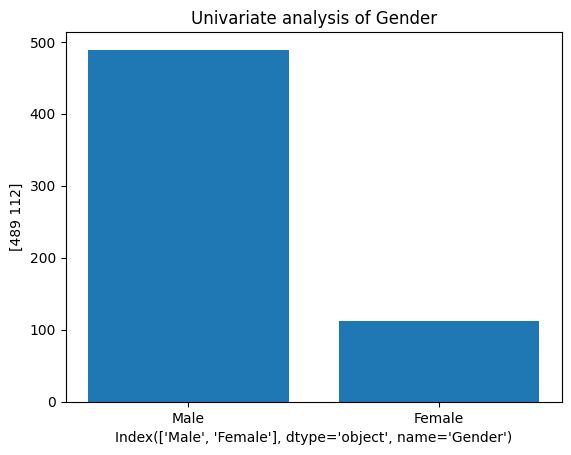

Gender
Male      489
Female    112
Name: count, dtype: int64


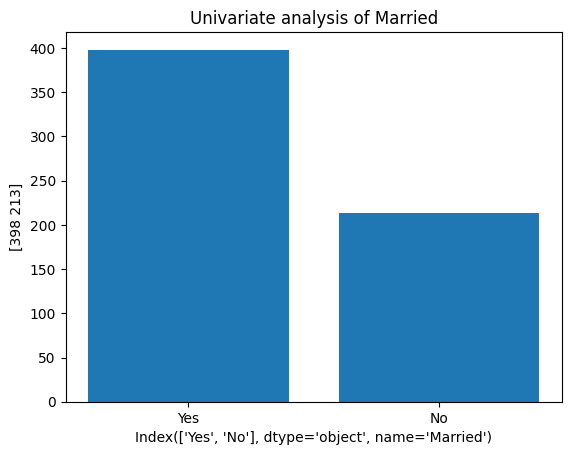

Married
Yes    398
No     213
Name: count, dtype: int64


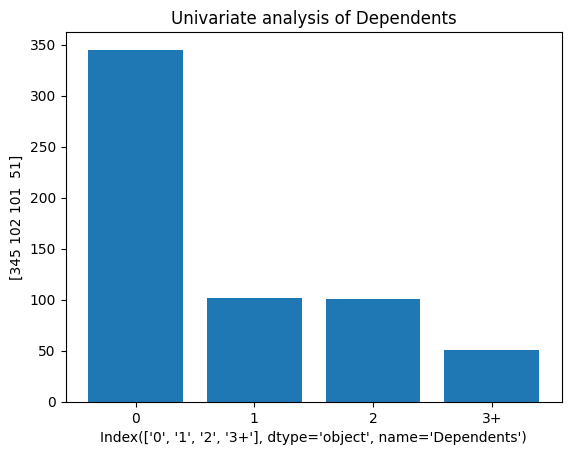

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64


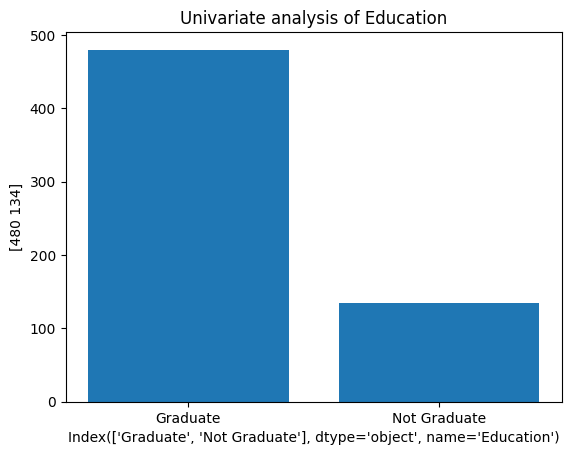

Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64


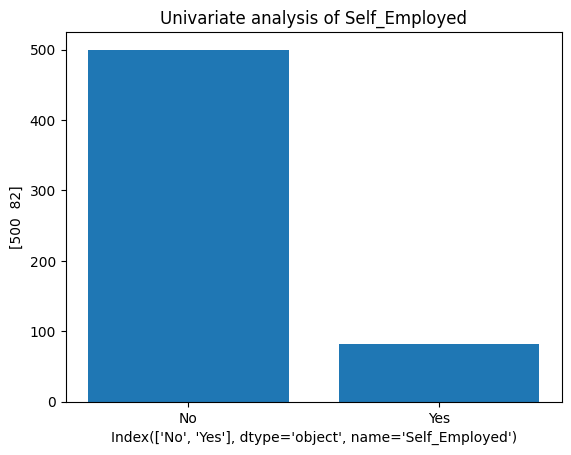

Self_Employed
No     500
Yes     82
Name: count, dtype: int64


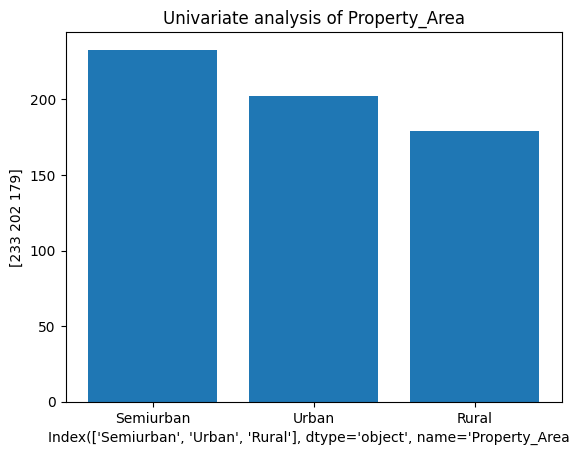

Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64


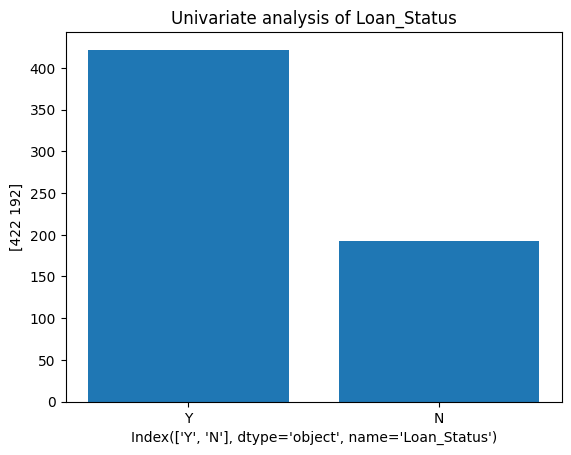

Loan_Status
Y    422
N    192
Name: count, dtype: int64


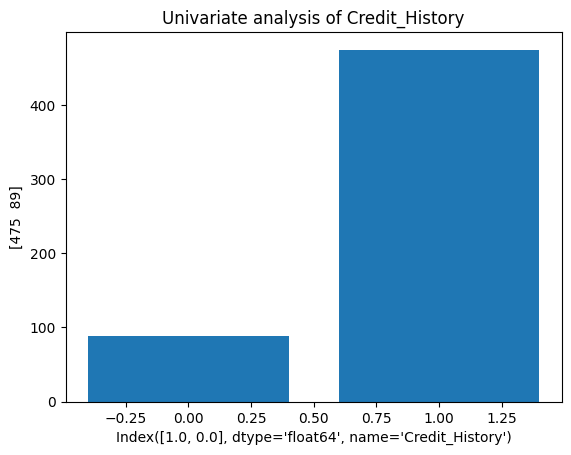

Credit_History
1.0    475
0.0     89
Name: count, dtype: int64


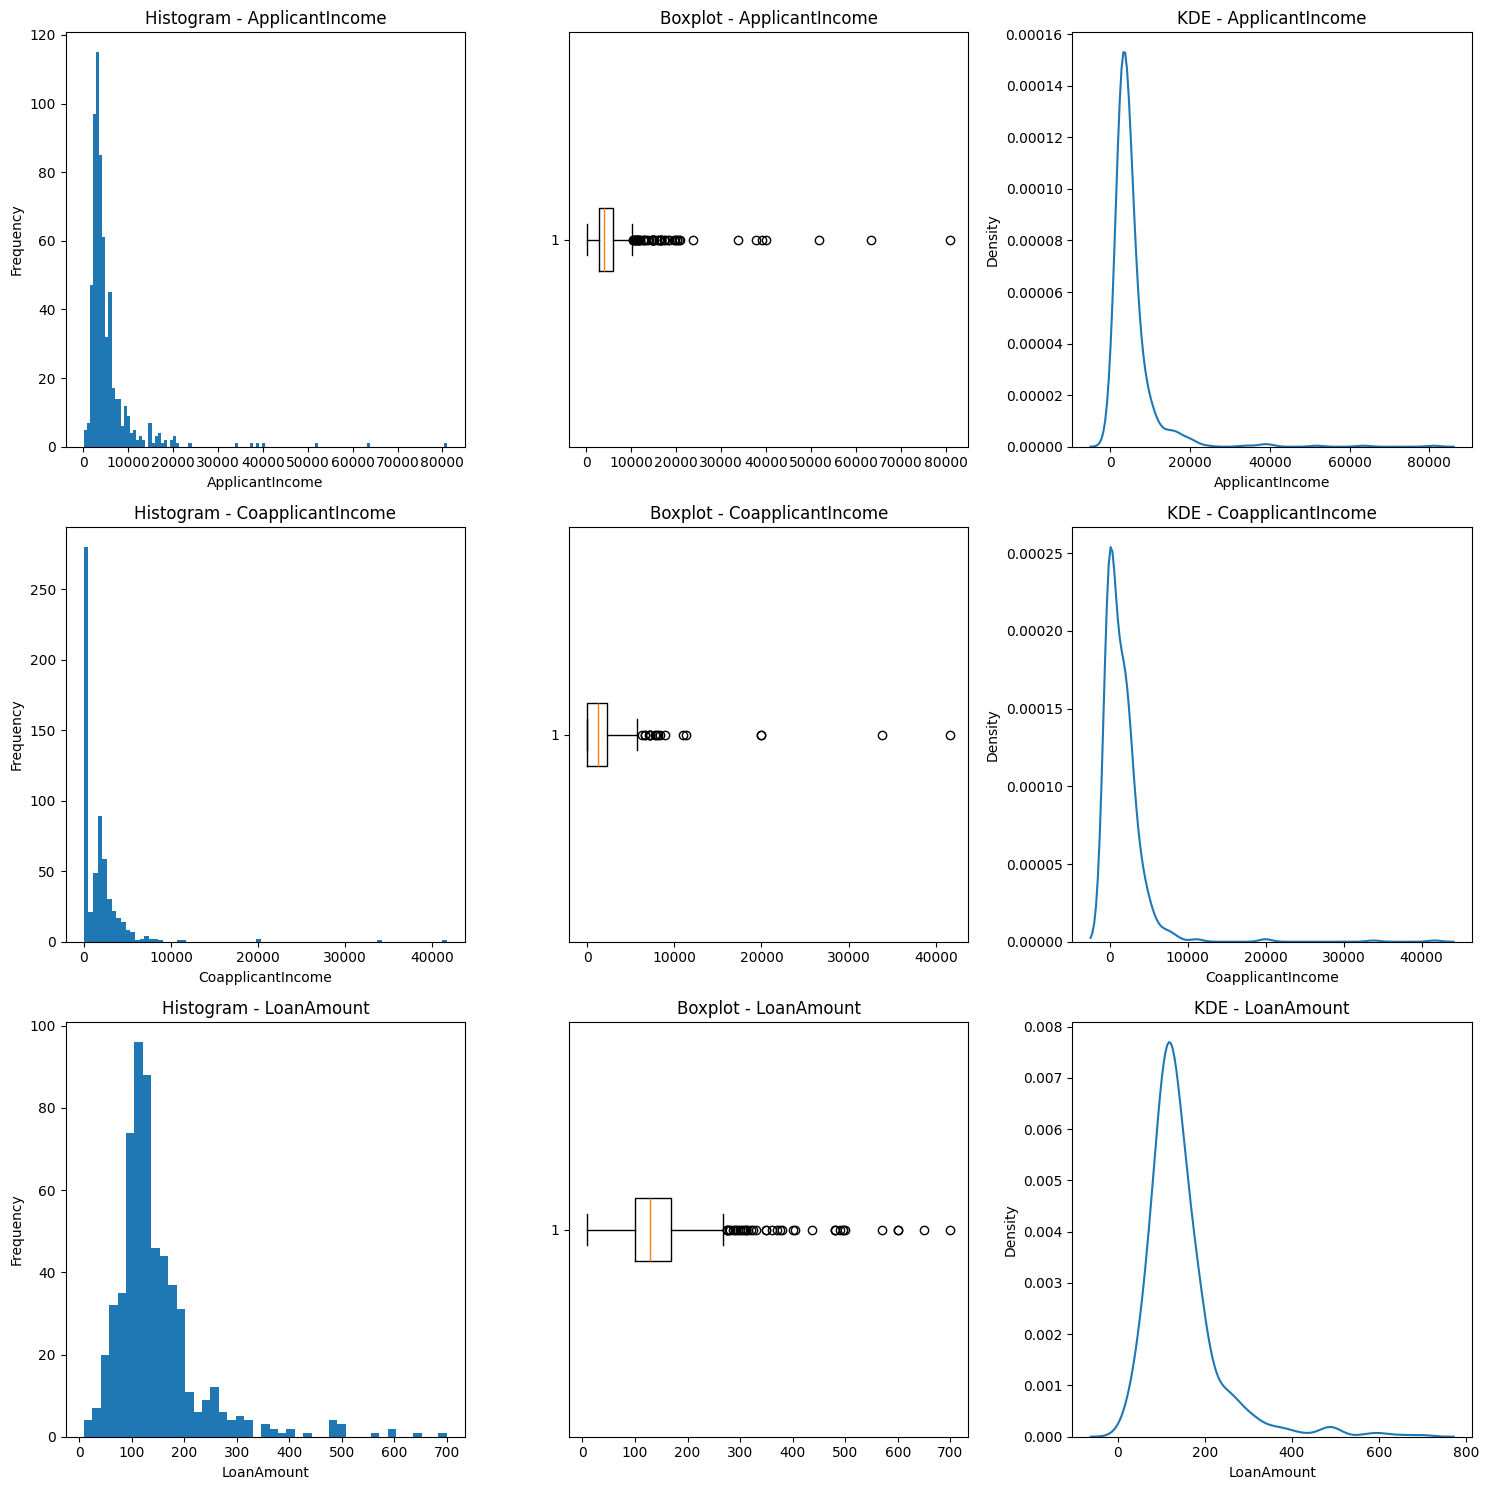



Feature: ApplicantIncome

Descriptive Statistics:
count      614.000000
mean      5403.459283
std       6109.041673
min        150.000000
25%       2877.500000
50%       3812.500000
75%       5795.000000
max      81000.000000
Name: ApplicantIncome, dtype: float64

Skewness: 6.54
Highly right-skewed.


Feature: CoapplicantIncome

Descriptive Statistics:
count      614.000000
mean      1621.245798
std       2926.248369
min          0.000000
25%          0.000000
50%       1188.500000
75%       2297.250000
max      41667.000000
Name: CoapplicantIncome, dtype: float64

Skewness: 7.49
Highly right-skewed.


Feature: LoanAmount

Descriptive Statistics:
count    592.000000
mean     146.412162
std       85.587325
min        9.000000
25%      100.000000
50%      128.000000
75%      168.000000
max      700.000000
Name: LoanAmount, dtype: float64

Skewness: 2.68
Highly right-skewed.
Correlation Matrix
                   ApplicantIncome  CoapplicantIncome  LoanAmount  \
ApplicantIncome          

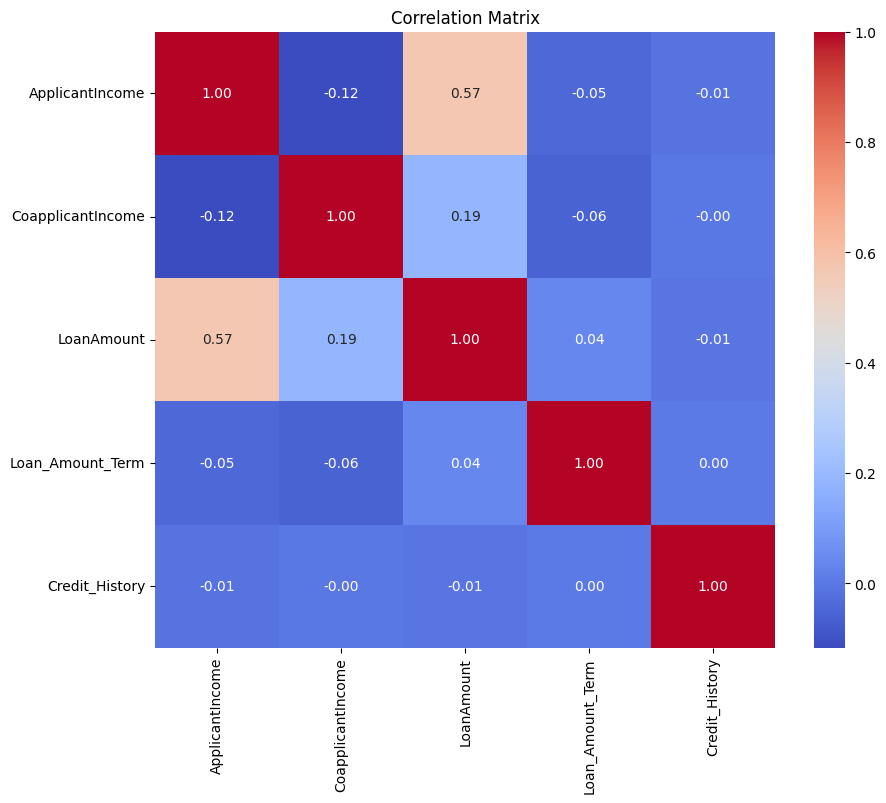


Top 5 Positive Correlations
ApplicantIncome    LoanAmount          0.570909
CoapplicantIncome  LoanAmount          0.188619
LoanAmount         Loan_Amount_Term    0.039447
Credit_History     Loan_Amount_Term    0.001470
CoapplicantIncome  Credit_History     -0.002056
dtype: float64

Top 5 Negative Correlations
ApplicantIncome    CoapplicantIncome   -0.116605
CoapplicantIncome  Loan_Amount_Term    -0.059878
ApplicantIncome    Loan_Amount_Term    -0.045306
                   Credit_History      -0.014715
Credit_History     LoanAmount          -0.008433
dtype: float64

Highly Correlated Features (|r| >= 0.8)
No highly correlated features found.

Available Columns:
----------------------------------------
1. Loan_ID
2. Gender
3. Married
4. Dependents
5. Education
6. Self_Employed
7. ApplicantIncome
8. CoapplicantIncome
9. LoanAmount
10. Loan_Amount_Term
11. Credit_History
12. Property_Area
13. Loan_Status



Enter the number corresponding to the target column:  9



Selected Target: LoanAmount

Detected Problem Type : Regression


Press Enter to accept or type 'R' for Regression or 'C' for Classification:  



Scatter Plots


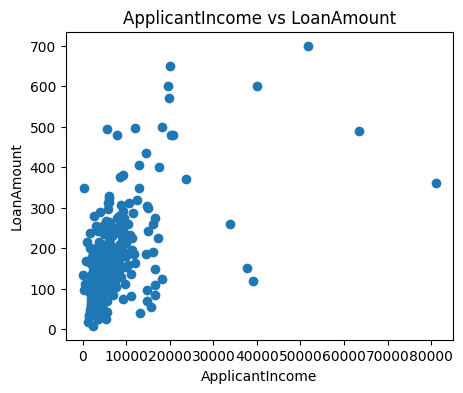

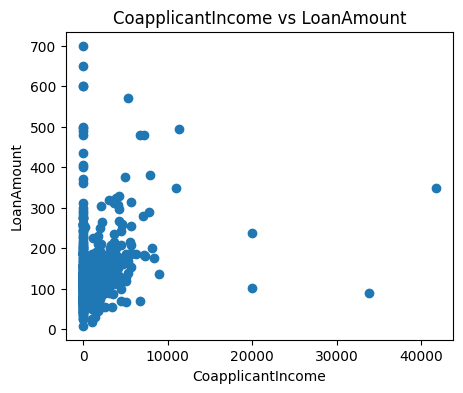


Categorical Feature vs Target


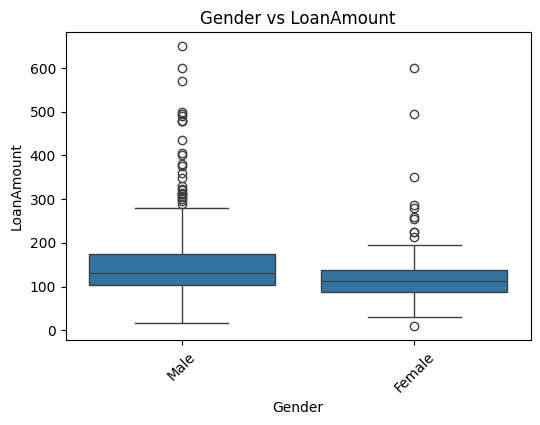

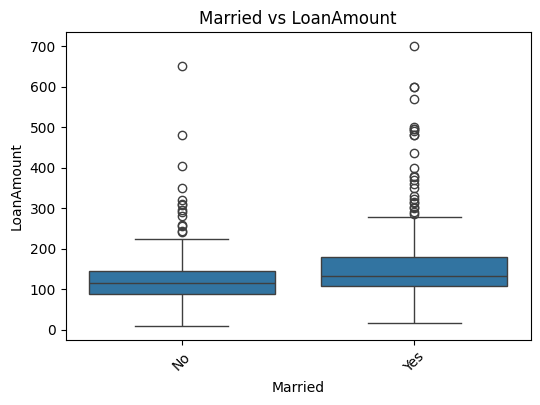

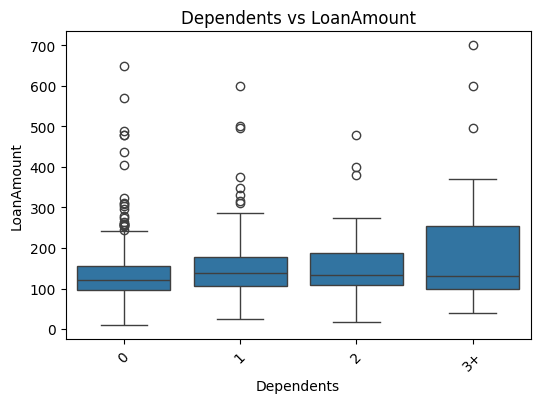

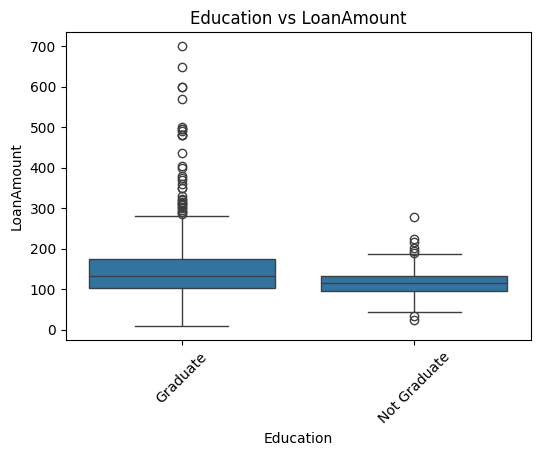

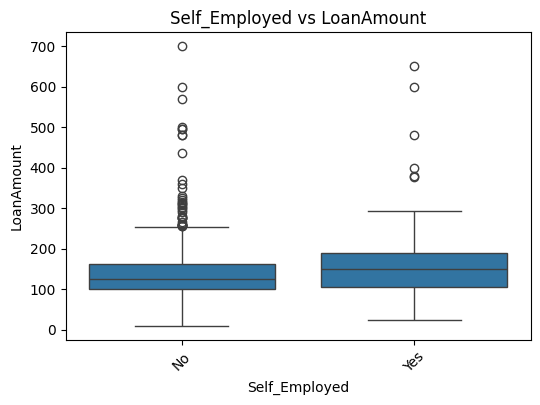

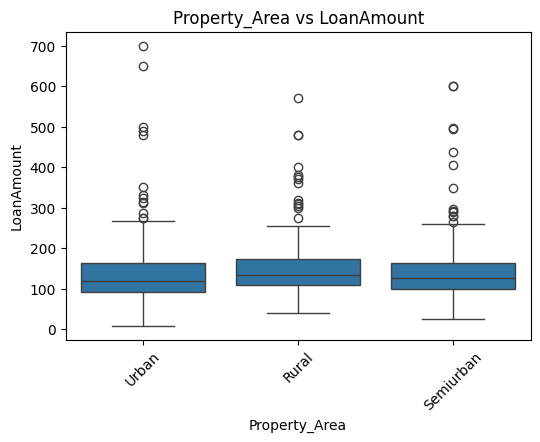

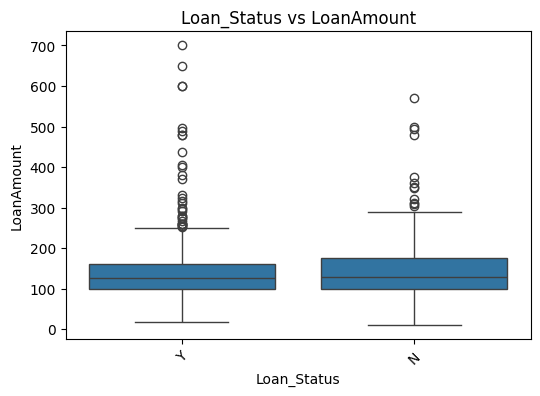

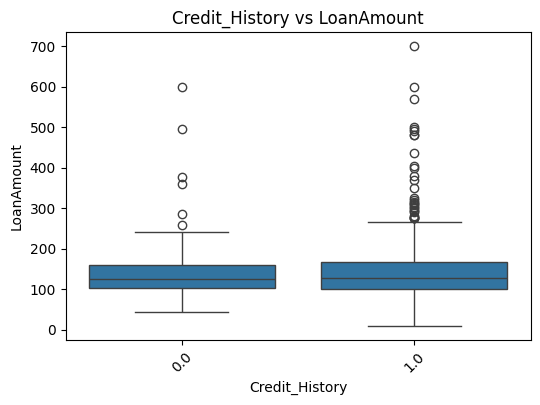

In [20]:
perform_eda()